In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [8]:
csv_data = """perso,agent_picks_24_04,total_compositions_24_04,pick_rate_24_04,agent_picks_01_05,total_compositions_01_05,pick_rate_01_05
neon,372,460,0.81,433,528,0.82
omen,233,460,0.51,266,528,0.5
viper,230,460,0.5,265,528,0.5
fade,164,460,0.36,188,528,0.36
waylay,167,460,0.36,172,528,0.33
skye,155,460,0.34,175,528,0.33
astra,115,460,0.25,132,528,0.25
sova,111,460,0.24,135,528,0.26
brimstone,104,460,0.23,115,528,0.22
cypher,106,460,0.23,123,528,0.23
raze,80,460,0.17,101,528,0.19
phoenix,70,460,0.15,84,528,0.16
chamber,58,460,0.13,63,528,0.12
killjoy,62,460,0.13,70,528,0.13
vyse,57,460,0.12,67,528,0.13
jett,43,460,0.09,51,528,0.1
tejo,43,460,0.09,49,528,0.09
kayo,30,460,0.07,36,528,0.07
breach,27,460,0.06,30,528,0.06
harbor,23,460,0.05,32,528,0.06
veto,22,460,0.05,23,528,0.04
deadlock,11,460,0.02,12,528,0.02
gekko,4,460,0.01,4,528,0.01
iso,4,460,0.01,5,528,0.01
sage,6,460,0.01,8,528,0.02
miks,2,460,0.0,2,528,0.0
yoru,1,460,0.0,1,528,0.0
"""

df = pd.read_csv(StringIO(csv_data))
df.head()

,perso,agent_picks_24_04,total_compositions_24_04,pick_rate_24_04,agent_picks_01_05,total_compositions_01_05,pick_rate_01_05
0,neon,372,460,0.81,433,528,0.82
1,omen,233,460,0.51,266,528,0.50
2,viper,230,460,0.50,265,528,0.50
3,fade,164,460,0.36,188,528,0.36
4,waylay,167,460,0.36,172,528,0.33


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   perso                     27 non-null     object 
 1   agent_picks_24_04         27 non-null     int64  
 2   total_compositions_24_04  27 non-null     int64  
 3   pick_rate_24_04           27 non-null     float64
 4   agent_picks_01_05         27 non-null     int64  
 5   total_compositions_01_05  27 non-null     int64  
 6   pick_rate_01_05           27 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 1.6+ KB


In [12]:
df.describe()

,agent_picks_24_04,total_compositions_24_04,pick_rate_24_04,agent_picks_01_05,total_compositions_01_05,pick_rate_01_05
count,27.000000,27.0,27.000000,27.000000,27.0,27.000000
mean,85.185185,460.0,0.184815,97.851852,528.0,0.185556
std,88.653620,0.0,0.193617,101.738996,0.0,0.192580
min,1.000000,460.0,0.000000,1.000000,528.0,0.000000
25%,22.500000,460.0,0.050000,26.500000,528.0,0.050000
50%,58.000000,460.0,0.130000,67.000000,528.0,0.130000
75%,113.000000,460.0,0.245000,133.500000,528.0,0.255000
max,372.000000,460.0,0.810000,433.000000,528.0,0.820000


In [14]:
print("Doublons :", df.duplicated().sum())
print("\nValeurs manquantes :")
display(df.isna().sum())

Doublons : 0

Valeurs manquantes :


perso                       0
agent_picks_24_04           0
total_compositions_24_04    0
pick_rate_24_04             0
agent_picks_01_05           0
total_compositions_01_05    0
pick_rate_01_05             0
dtype: int64

In [16]:
df["delta_pick_rate"] = df["pick_rate_01_05"] - df["pick_rate_24_04"]
df["delta_pick_rate_pp"] = df["delta_pick_rate"] * 100
df["delta_picks"] = df["agent_picks_01_05"] - df["agent_picks_24_04"]

df["relative_growth_picks"] = (
    df["delta_picks"] / df["agent_picks_24_04"].replace(0, pd.NA)
)

df.sort_values("pick_rate_01_05", ascending=False)

,perso,agent_picks_24_04,total_compositions_24_04,pick_rate_24_04,agent_picks_01_05,total_compositions_01_05,pick_rate_01_05,delta_pick_rate,delta_pick_rate_pp,delta_picks,relative_growth_picks
0,neon,372,460,0.81,433,528,0.82,0.01,1.0,61,0.163978
1,omen,233,460,0.51,266,528,0.50,-0.01,-1.0,33,0.141631
2,viper,230,460,0.50,265,528,0.50,0.00,0.0,35,0.152174
3,fade,164,460,0.36,188,528,0.36,0.00,0.0,24,0.146341
4,waylay,167,460,0.36,172,528,0.33,-0.03,-3.0,5,0.029940
5,skye,155,460,0.34,175,528,0.33,-0.01,-1.0,20,0.129032
7,sova,111,460,0.24,135,528,0.26,0.02,2.0,24,0.216216
6,astra,115,460,0.25,132,528,0.25,0.00,0.0,17,0.147826
9,cypher,106,460,0.23,123,528,0.23,0.00,0.0,17,0.160377
8,brimstone,104,460,0.23,115,528,0.22,-0.01,-1.0,11,0.105769


In [18]:
MIN_PICKS_CURRENT = 20

df_analysis = df[df["agent_picks_01_05"] >= MIN_PICKS_CURRENT].copy()

df_analysis[[
    "perso",
    "agent_picks_24_04",
    "agent_picks_01_05",
    "pick_rate_24_04",
    "pick_rate_01_05",
    "delta_pick_rate_pp",
    "delta_picks",
]]

,perso,agent_picks_24_04,agent_picks_01_05,pick_rate_24_04,pick_rate_01_05,delta_pick_rate_pp,delta_picks
0,neon,372,433,0.81,0.82,1.0,61
1,omen,233,266,0.51,0.50,-1.0,33
2,viper,230,265,0.50,0.50,0.0,35
3,fade,164,188,0.36,0.36,0.0,24
4,waylay,167,172,0.36,0.33,-3.0,5
5,skye,155,175,0.34,0.33,-1.0,20
6,astra,115,132,0.25,0.25,0.0,17
7,sova,111,135,0.24,0.26,2.0,24
8,brimstone,104,115,0.23,0.22,-1.0,11
9,cypher,106,123,0.23,0.23,0.0,17


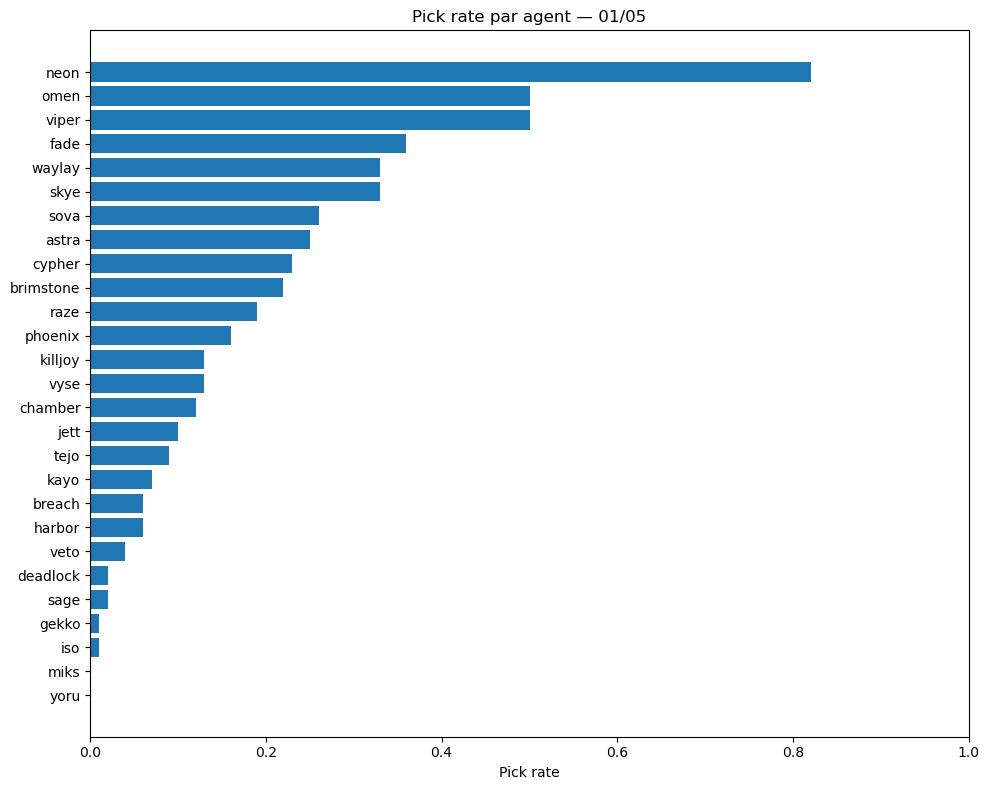

In [20]:
plot_df = df.sort_values("pick_rate_01_05", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["perso"], plot_df["pick_rate_01_05"])
plt.xlabel("Pick rate")
plt.title("Pick rate par agent — 01/05")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

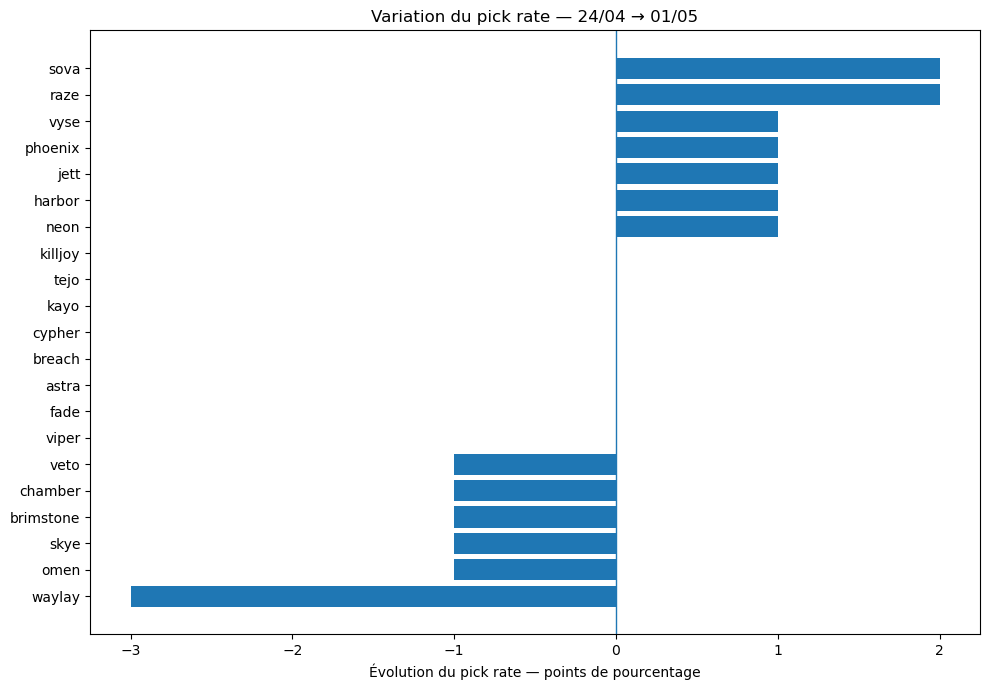

In [22]:
plot_df = df_analysis.sort_values("delta_pick_rate_pp", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["perso"], plot_df["delta_pick_rate_pp"])
plt.axvline(0, linewidth=1)
plt.xlabel("Évolution du pick rate — points de pourcentage")
plt.title("Variation du pick rate — 24/04 → 01/05")
plt.tight_layout()
plt.show()

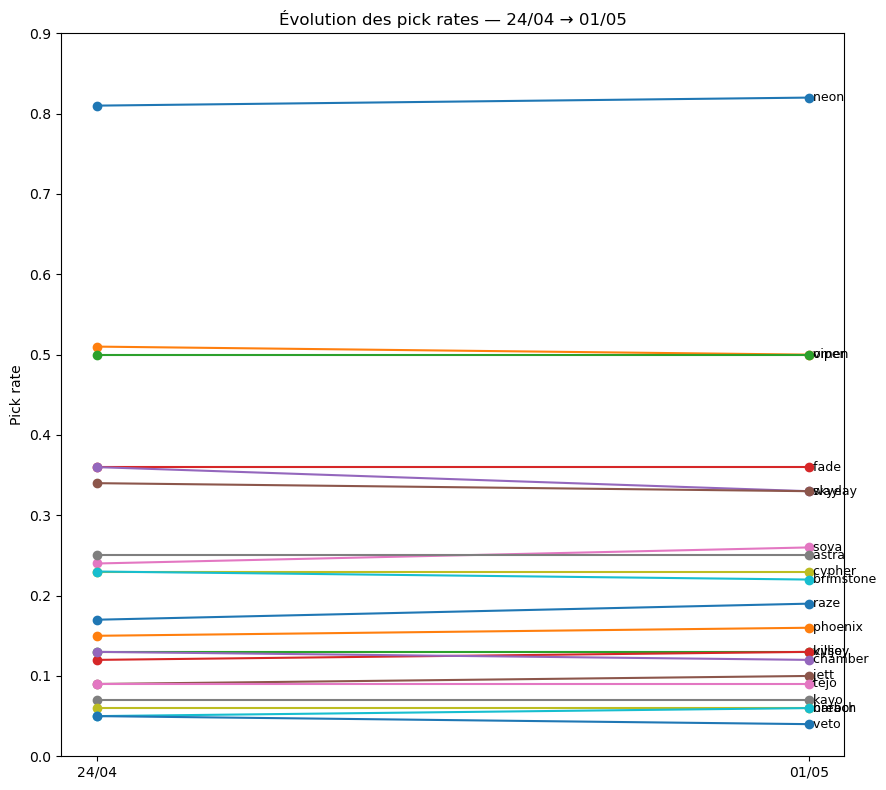

In [24]:
plot_df = df_analysis.sort_values("pick_rate_01_05", ascending=False)

plt.figure(figsize=(9, 8))

for _, row in plot_df.iterrows():
    plt.plot(
        ["24/04", "01/05"],
        [row["pick_rate_24_04"], row["pick_rate_01_05"]],
        marker="o"
    )
    plt.text(
        "01/05",
        row["pick_rate_01_05"],
        " " + row["perso"],
        va="center",
        fontsize=9
    )

plt.ylabel("Pick rate")
plt.title("Évolution des pick rates — 24/04 → 01/05")
plt.ylim(0, df_analysis[["pick_rate_24_04", "pick_rate_01_05"]].max().max() + 0.08)
plt.tight_layout()
plt.show()

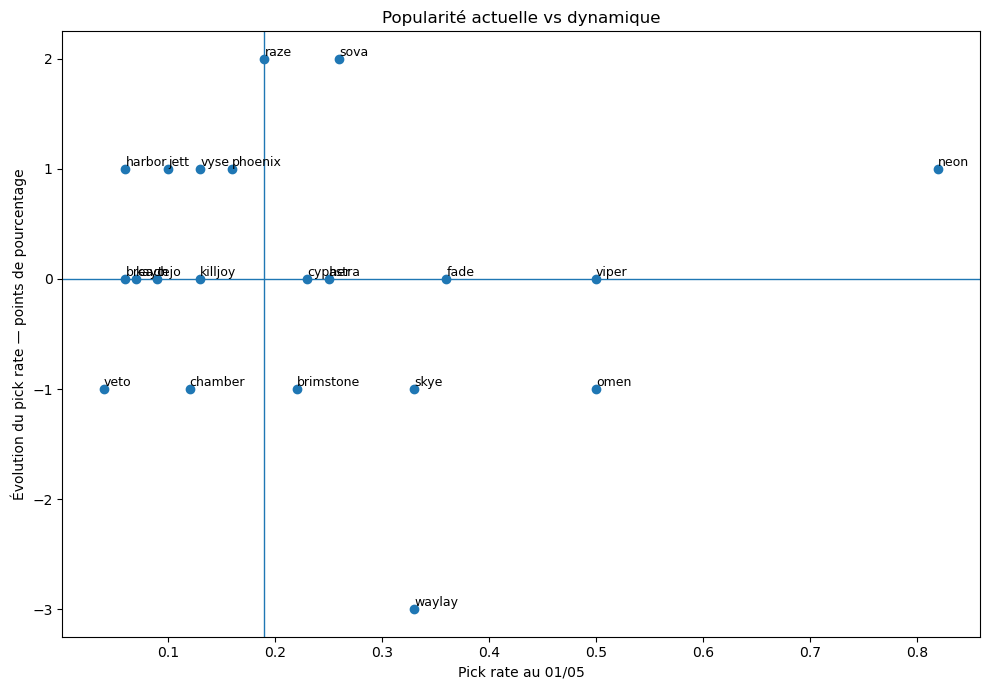

In [26]:
plot_df = df_analysis.copy()

plt.figure(figsize=(10, 7))
plt.scatter(plot_df["pick_rate_01_05"], plot_df["delta_pick_rate_pp"])

for _, row in plot_df.iterrows():
    plt.text(
        row["pick_rate_01_05"],
        row["delta_pick_rate_pp"],
        row["perso"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.axhline(0, linewidth=1)
plt.axvline(plot_df["pick_rate_01_05"].median(), linewidth=1)
plt.xlabel("Pick rate au 01/05")
plt.ylabel("Évolution du pick rate — points de pourcentage")
plt.title("Popularité actuelle vs dynamique")
plt.tight_layout()
plt.show()

In [28]:
print("Top 10 pick rate au 01/05")
display(
    df.sort_values("pick_rate_01_05", ascending=False)[
        ["perso", "pick_rate_01_05", "agent_picks_01_05"]
    ].head(10)
)

print("\nPlus fortes progressions")
display(
    df_analysis.sort_values("delta_pick_rate", ascending=False)[
        ["perso", "pick_rate_24_04", "pick_rate_01_05", "delta_pick_rate_pp", "delta_picks"]
    ].head(10)
)

print("\nPlus fortes baisses")
display(
    df_analysis.sort_values("delta_pick_rate", ascending=True)[
        ["perso", "pick_rate_24_04", "pick_rate_01_05", "delta_pick_rate_pp", "delta_picks"]
    ].head(10)
)

Top 10 pick rate au 01/05


,perso,pick_rate_01_05,agent_picks_01_05
0,neon,0.82,433
1,omen,0.50,266
2,viper,0.50,265
3,fade,0.36,188
4,waylay,0.33,172
5,skye,0.33,175
7,sova,0.26,135
6,astra,0.25,132
9,cypher,0.23,123
8,brimstone,0.22,115



Plus fortes progressions


,perso,pick_rate_24_04,pick_rate_01_05,delta_pick_rate_pp,delta_picks
7,sova,0.24,0.26,2.0,24
10,raze,0.17,0.19,2.0,21
15,jett,0.09,0.10,1.0,8
14,vyse,0.12,0.13,1.0,10
11,phoenix,0.15,0.16,1.0,14
19,harbor,0.05,0.06,1.0,9
0,neon,0.81,0.82,1.0,61
6,astra,0.25,0.25,0.0,17
9,cypher,0.23,0.23,0.0,17
13,killjoy,0.13,0.13,0.0,8



Plus fortes baisses


,perso,pick_rate_24_04,pick_rate_01_05,delta_pick_rate_pp,delta_picks
4,waylay,0.36,0.33,-3.0,5
1,omen,0.51,0.50,-1.0,33
5,skye,0.34,0.33,-1.0,20
8,brimstone,0.23,0.22,-1.0,11
12,chamber,0.13,0.12,-1.0,5
20,veto,0.05,0.04,-1.0,1
2,viper,0.50,0.50,0.0,35
3,fade,0.36,0.36,0.0,24
6,astra,0.25,0.25,0.0,17
18,breach,0.06,0.06,0.0,3


In [30]:
df_long_24 = df[[
    "perso",
    "agent_picks_24_04",
    "total_compositions_24_04",
    "pick_rate_24_04"
]].rename(columns={
    "agent_picks_24_04": "agent_picks",
    "total_compositions_24_04": "total_compositions",
    "pick_rate_24_04": "pick_rate",
})

df_long_24["date"] = "2026-04-24"

df_long_01 = df[[
    "perso",
    "agent_picks_01_05",
    "total_compositions_01_05",
    "pick_rate_01_05"
]].rename(columns={
    "agent_picks_01_05": "agent_picks",
    "total_compositions_01_05": "total_compositions",
    "pick_rate_01_05": "pick_rate",
})

df_long_01["date"] = "2026-05-01"

df_long = pd.concat([df_long_24, df_long_01], ignore_index=True)
df_long = df_long[["date", "perso", "agent_picks", "total_compositions", "pick_rate"]]
df_long["date"] = pd.to_datetime(df_long["date"])

df_long.head()

,date,perso,agent_picks,total_compositions,pick_rate
0,2026-04-24,neon,372,460,0.81
1,2026-04-24,omen,233,460,0.51
2,2026-04-24,viper,230,460,0.50
3,2026-04-24,fade,164,460,0.36
4,2026-04-24,waylay,167,460,0.36


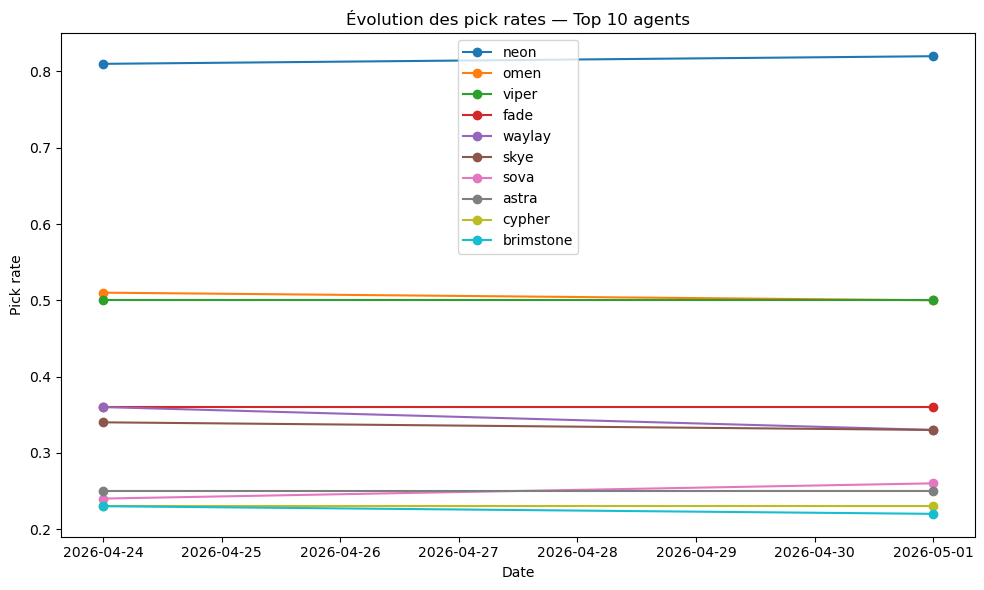

In [32]:
top_agents = (
    df.sort_values("pick_rate_01_05", ascending=False)
    .head(10)["perso"]
    .tolist()
)

plot_df = df_long[df_long["perso"].isin(top_agents)]

plt.figure(figsize=(10, 6))

for agent in top_agents:
    agent_df = plot_df[plot_df["perso"] == agent].sort_values("date")
    plt.plot(agent_df["date"], agent_df["pick_rate"], marker="o", label=agent)

plt.xlabel("Date")
plt.ylabel("Pick rate")
plt.title("Évolution des pick rates — Top 10 agents")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
top_current = df.sort_values("pick_rate_01_05", ascending=False).head(5)
top_growth = df_analysis.sort_values("delta_pick_rate", ascending=False).head(5)
top_decline = df_analysis.sort_values("delta_pick_rate", ascending=True).head(5)

print("Agents les plus joués au 01/05 :")
display(top_current[["perso", "pick_rate_01_05", "agent_picks_01_05"]])

print("\nAgents en plus forte progression :")
display(top_growth[["perso", "pick_rate_24_04", "pick_rate_01_05", "delta_pick_rate_pp"]])

print("\nAgents en plus forte baisse :")
display(top_decline[["perso", "pick_rate_24_04", "pick_rate_01_05", "delta_pick_rate_pp"]])

Agents les plus joués au 01/05 :


,perso,pick_rate_01_05,agent_picks_01_05
0,neon,0.82,433
1,omen,0.50,266
2,viper,0.50,265
3,fade,0.36,188
4,waylay,0.33,172



Agents en plus forte progression :


,perso,pick_rate_24_04,pick_rate_01_05,delta_pick_rate_pp
7,sova,0.24,0.26,2.0
10,raze,0.17,0.19,2.0
15,jett,0.09,0.10,1.0
14,vyse,0.12,0.13,1.0
11,phoenix,0.15,0.16,1.0



Agents en plus forte baisse :


,perso,pick_rate_24_04,pick_rate_01_05,delta_pick_rate_pp
4,waylay,0.36,0.33,-3.0
1,omen,0.51,0.50,-1.0
5,skye,0.34,0.33,-1.0
8,brimstone,0.23,0.22,-1.0
12,chamber,0.13,0.12,-1.0
